# Hyperbolic Word-Level Evaluation — Poincaré Embeddings on WordNet & HyperLex

**Author:** Morchid Saad — INSEA — 3D Smart Factory

**Project:** Geometry-Aware Optimal Transport for Interpretable Semantic Textual Similarity (PFE)

## Abstract

This notebook trains Poincaré ball embeddings on the WordNet noun hypernymy graph (Nickel & Kiela, 2017) and evaluates them on lexical entailment (HyperLex, Vulić et al., 2017). The objective is to verify, at the word level, that hyperbolic geometry encodes hierarchical structure, before incorporating hyperbolic costs into Word Mover's Distance for sentence similarity.

We compare three scoring methods on HyperLex:

1. **Euclidean distance** — flat-geometry baseline
2. **Poincaré distance** — hyperbolic but symmetric
3. **Nickel asymmetric score** — hyperbolic and directional

We additionally compute reconstruction performance on the WordNet noun hierarchy itself, providing reference numbers against Nickel & Kiela's published results.

This is the second notebook in the experimental pipeline. The geometric comparison notebook established that projecting Euclidean GloVe vectors into hyperbolic space via the exponential map does not improve WMD-based sentence similarity on STS-B — all three geometries performed within 0.003 Spearman of each other. This notebook asks the prerequisite question: does hyperbolic geometry capture hierarchical structure *at all* when embeddings are natively trained in hyperbolic space? If the answer is no, that null result would be trivially explained. If yes, the bottleneck is the training signal, not the geometry — and the Tifrea Poincaré GloVe notebook tests whether general-vocabulary hyperbolic embeddings can transfer the advantage to STS-B.

## Notebook structure

| Section | Content |
|---|---|
| 1 | Setup — imports, configuration, reproducibility seeds |
| 2 | Data preparation — WordNet noun closure |
| 3 | Training — main 10D model + side mammals 2D model with visualizations |
| 4 | Model inspection — sanity checks and qualitative neighbors |
| 5 | Diagnostic plot — vector norm vs. WordNet hierarchy depth |
| 6 | WordNet evaluation — Reconstruction |
| 7 | HyperLex dataset — loading and exploratory overview |
| 8 | HyperLex methodology — sense-disambiguation diagnostics |
| 9 | HyperLex evaluation — three-method comparison |
| 10 | Subset analysis — Spearman by relation type |
| 11 | Qualitative neighbor analysis — interpretability evidence |
| 12 | Summary — final results table and conclusions |

## 1. Setup

Standard imports, configuration constants, and random seeds for reproducibility.

In [1]:
# Standard library
import os
import random
import urllib.request
import zipfile
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from tqdm import tqdm

# NLP / embeddings
import nltk
from nltk.corpus import wordnet as wn
from gensim.models.poincare import (
    PoincareModel,
    PoincareRelations,
    PoincareKeyedVectors,
    ReconstructionEvaluation,
)
from gensim.models import KeyedVectors

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

print("Imports OK")

Imports OK


In [2]:
# ---- Configuration --------------------------------------------------------
# Directory layout
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints"
FIGURES_DIR = BASE_DIR / "figures" / "hyperbolic_evaluation"
for d in [DATA_DIR, MODELS_DIR, CHECKPOINTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# File paths
NOUN_CLOSURE_FILE = DATA_DIR / "noun_closure.tsv"
MAMMALS_CLOSURE_FILE = DATA_DIR / "mammals_closure.tsv"
HYPERLEX_ZIP = DATA_DIR / "hyperlex-data.zip"
HYPERLEX_DIR = DATA_DIR / "hyperlex"
HYPERLEX_NOUNS_FILE = HYPERLEX_DIR / "nouns-verbs" / "hyperlex-nouns.txt"

MAIN_MODEL_PATH = MODELS_DIR / "poincare_nouns_dim10.model"
MAIN_VEC_PATH = MODELS_DIR / "poincare_nouns_dim10.vec"
MAMMALS_MODEL_PATH = MODELS_DIR / "poincare_mammals_dim2.model"

# Training hyperparameters
HP = {
    "size": 10,
    "negative": 10,
    "burn_in": 10,
    "regularization_coeff": 1.0,
    "epochs": 200,
    "batch_size": 10,
    "checkpoint_every": 50,  # save model every N epochs
}

# Mammals 2D side model (for visualization)
HP_MAMMALS = {
    "size": 2,
    "negative": 10,
    "burn_in": 10,
    "regularization_coeff": 1.0,
    "epochs_early_snapshot": 20,   # first snapshot during training
    "epochs_total": 200,           # full training duration
    "batch_size": 10,
}

print(f"Working directory: {BASE_DIR}")
print(f"Main model dim:    {HP['size']}")
print(f"Mammals model dim: {HP_MAMMALS['size']}")

Working directory: /home/saad1/pfe
Main model dim:    10
Mammals model dim: 2


## 2. Data preparation

We extract the WordNet noun hypernymy graph and its transitive closure. Each line of the output file is `(hyponym_synset, hypernym_synset)` — the input format expected by gensim's `PoincareModel`.

We also extract a separate, smaller closure restricted to the **mammals subtree**, which we'll use to train a 2D side model whose embeddings can be plotted directly in the Poincaré disk for visualization.

In [3]:
# Ensure WordNet is downloaded
nltk.download('wordnet', quiet=True)
print("WordNet ready")

WordNet ready


In [4]:
def write_closure(synsets, output_file, label):
    """Write transitive closure of hypernymy edges for the given synsets."""
    if output_file.exists():
        with open(output_file) as f:
            n_lines = sum(1 for _ in f)
        print(f"[{label}] {output_file.name} already exists ({n_lines} pairs)")
        return

    pairs = set()
    for synset in tqdm(synsets, desc=f"Building {label} closure"):
        for ancestor in synset.closure(lambda s: s.hypernyms()):
            pairs.add((synset.name(), ancestor.name()))

    with open(output_file, "w") as f:
        for hypo, hyper in pairs:
            f.write(f"{hypo}\t{hyper}\n")
    print(f"[{label}] {len(pairs):,} (hyponym, hypernym) pairs → {output_file.name}")


# Full noun hierarchy
all_nouns = list(wn.all_synsets(pos='n'))
print(f"WordNet nouns total: {len(all_nouns):,}")
write_closure(all_nouns, NOUN_CLOSURE_FILE, "nouns")

# Mammals subtree (for 2D visualization)
mammal_root = wn.synset("mammal.n.01")
mammal_subtree = list(mammal_root.closure(lambda s: s.hyponyms())) + [mammal_root]
print(f"\nMammal subtree synsets: {len(mammal_subtree):,}")
write_closure(mammal_subtree, MAMMALS_CLOSURE_FILE, "mammals")

WordNet nouns total: 82,115


Building nouns closure: 100%|██████████████████████████████████████████████████| 82115/82115 [00:02<00:00, 38621.34it/s]


[nouns] 663,508 (hyponym, hypernym) pairs → noun_closure.tsv

Mammal subtree synsets: 1,170


Building mammals closure: 100%|██████████████████████████████████████████████████| 1170/1170 [00:00<00:00, 17185.80it/s]

[mammals] 17,222 (hyponym, hypernym) pairs → mammals_closure.tsv


## 3. Training

### 3.1 Main 10D model

We train Poincaré embeddings on the full WordNet noun closure with the configuration from the gensim reference notebook:

- 10 dimensions (fixed across all evaluations for consistency)
- 10 negative samples per positive
- 10 epochs of burn-in (low learning rate to settle near origin)
- L2 regularization coefficient 1.0
- 200 total training epochs
- Batch size 10

Training takes roughly 2–3 hours on a single CPU thread. We checkpoint every 50 epochs so the work is recoverable if the kernel restarts.

In [5]:
def train_main_model():
    """Train (or load) the main 10D Poincaré model on WordNet nouns."""
    if MAIN_MODEL_PATH.exists():
        print(f"Loading existing model from {MAIN_MODEL_PATH.name}")
        return PoincareModel.load(str(MAIN_MODEL_PATH))

    relations = PoincareRelations(file_path=str(NOUN_CLOSURE_FILE))
    model = PoincareModel(
        train_data=relations,
        size=HP["size"],
        negative=HP["negative"],
        burn_in=HP["burn_in"],
        regularization_coeff=HP["regularization_coeff"],
        seed=SEED,
    )

    n_chunks = HP["epochs"] // HP["checkpoint_every"]
    epochs_per_chunk = HP["checkpoint_every"]

    print(f"Training: {HP['epochs']} epochs in {n_chunks} chunks of "
          f"{epochs_per_chunk} epochs each (~30-45 min per chunk)")

    for chunk in range(n_chunks):
        epoch_at_end = (chunk + 1) * epochs_per_chunk
        print(f"\n>>> Chunk {chunk+1}/{n_chunks} → epoch {epoch_at_end}")
        model.train(epochs=epochs_per_chunk, batch_size=HP["batch_size"])
        ckpt = CHECKPOINTS_DIR / f"poincare_nouns_dim10_epoch_{epoch_at_end}.model"
        model.save(str(ckpt))
        print(f"    checkpoint saved: {ckpt.name}")

    # Final saves
    model.save(str(MAIN_MODEL_PATH))
    model.kv.save_word2vec_format(str(MAIN_VEC_PATH))
    print(f"\nFinal model saved: {MAIN_MODEL_PATH.name}")
    return model


main_model = train_main_model()
print(f"\nVocabulary size: {len(main_model.kv):,}")
print(f"Embedding dimension: {main_model.kv.vector_size}")

Training: 200 epochs in 4 chunks of 50 epochs each (~30-45 min per chunk)

>>> Chunk 1/4 → epoch 50
    checkpoint saved: poincare_nouns_dim10_epoch_50.model

>>> Chunk 2/4 → epoch 100
    checkpoint saved: poincare_nouns_dim10_epoch_100.model

>>> Chunk 3/4 → epoch 150
    checkpoint saved: poincare_nouns_dim10_epoch_150.model

>>> Chunk 4/4 → epoch 200
    checkpoint saved: poincare_nouns_dim10_epoch_200.model

Final model saved: poincare_nouns_dim10.model

Vocabulary size: 74,401
Embedding dimension: 10


### 3.2 Side mammals 2D model with training-stage visualization

To visualize how the geometry emerges during training, we train a separate 2-dimensional model on the mammals subtree only. We snapshot the embedding at epoch 20 (early training) and again after full convergence (epoch 200), then plot both side by side.

This is purely illustrative — the full thesis evaluation runs on the 10D main model. The 2D model exists to produce a striking visual that demonstrates how hierarchy organizes itself in the Poincaré disk.

Training mammals 2D model — early snapshot...


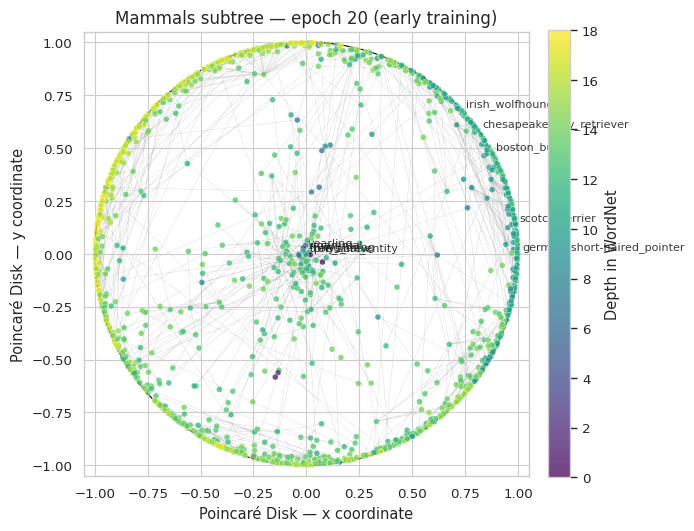

Saved figure: /home/saad1/pfe/figures/hyperbolic_evaluation/mammals_2d_epoch_20.png

Generic (near center):
  living_thing.n.01  (norm=0.0037, depth=4)
  tree_shrew.n.01  (norm=0.0040, depth=11)
  mammal.n.01  (norm=0.0139, depth=9)
  physical_entity.n.01  (norm=0.0186, depth=1)
  yearling.n.03  (norm=0.0202, depth=11)

Specific (near boundary):
  scotch_terrier.n.01  (norm=0.9986, depth=11)
  chesapeake_bay_retriever.n.01  (norm=0.9986, depth=12)
  boston_bull.n.01  (norm=0.9987, depth=11)
  irish_wolfhound.n.01  (norm=0.9987, depth=12)
  german_short-haired_pointer.n.01  (norm=0.9988, depth=12)

Early training — depth-norm correspondence not yet established


In [6]:
def get_wordnet_depth(synset_name, root=wn.synset("entity.n.01"), max_depth=20):
    """Compute depth of a synset in the WordNet hierarchy (0 = root)."""
    try:
        s = wn.synset(synset_name)
    except Exception:
        return None
    paths = s.hypernym_paths()
    if not paths:
        return 0
    return min(len(p) - 1 for p in paths)

def plot_poincare_disk(kv, title, output_path, point_size=18, label_top_n=10):
    """Plot 2D Poincaré embeddings as points on the unit disk, colored by depth."""
    synsets = list(kv.key_to_index.keys())
    coords  = np.array([kv[s] for s in synsets])
    depths  = np.array([get_wordnet_depth(s) for s in synsets])

    # Filter to synsets where we have a valid depth
    valid   = np.array([d is not None for d in depths])
    coords  = coords[valid]
    synsets = [s for s, v in zip(synsets, valid) if v]
    depths  = np.array([d for d, v in zip(depths, valid) if v])

    fig, ax = plt.subplots(figsize=(7, 7))

    # Draw the unit disk
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), color="black", linewidth=0.8)

    # --- Direct hypernym edges ---
    for synset_name in synsets:
        if synset_name not in kv.key_to_index:  # check vocabulary first
            continue
        try:
            s = wn.synset(synset_name)
        except Exception:
            continue
        child_coord = kv[synset_name]
        for hypernym in s.hypernyms():
            h_name = hypernym.name()
            if h_name not in kv.key_to_index:
                continue
            parent_coord = kv[h_name]
            ax.plot(
                [child_coord[0], parent_coord[0]],
                [child_coord[1], parent_coord[1]],
                color="gray",
                linewidth=0.3,
                alpha=0.3,
                zorder=0,  # draw behind points
            )

    # --- Scatter colored by depth ---
    sc = ax.scatter(
        coords[:, 0], coords[:, 1],
        c=depths, cmap="viridis", s=point_size, alpha=0.75,
        edgecolors="white", linewidths=0.3,
        zorder=2,
    )

    # --- Annotate low-norm (generic) and high-norm (specific) points ---
    norms       = np.linalg.norm(coords, axis=1)
    interesting = (
        list(np.argsort(norms)[: label_top_n // 2]) +
        list(np.argsort(norms)[-label_top_n // 2:])
    )
    for idx in interesting:
        name = synsets[idx].split(".")[0]
        ax.annotate(
            name, coords[idx],
            fontsize=8, alpha=0.9,
            xytext=(3, 3), textcoords="offset points",
            zorder=3,
        )

    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Poincaré Disk — x coordinate")
    ax.set_ylabel("Poincaré Disk — y coordinate")

    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Depth in WordNet")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure: {output_path}")
    
    half = label_top_n // 2

    print()
    print("Generic (near center):")
    for idx in interesting[:half]:
        print(f"  {synsets[idx]}  (norm={norms[idx]:.4f}, depth={depths[idx]})")
        
    print("\nSpecific (near boundary):")
    for idx in interesting[half:]:
        print(f"  {synsets[idx]}  (norm={norms[idx]:.4f}, depth={depths[idx]})")

# Train mammals 2D model in two stages: snapshot early, then continue to convergence
print("Training mammals 2D model — early snapshot...")
mammals_relations = PoincareRelations(file_path=str(MAMMALS_CLOSURE_FILE))
mammals_model = PoincareModel(
    train_data=mammals_relations,
    size=HP_MAMMALS["size"],
    negative=HP_MAMMALS["negative"],
    burn_in=HP_MAMMALS["burn_in"],
    regularization_coeff=HP_MAMMALS["regularization_coeff"],
    seed=SEED,
)
mammals_model.train(
    epochs=HP_MAMMALS["epochs_early_snapshot"],
    batch_size=HP_MAMMALS["batch_size"],
)

# Snapshot at early training
plot_poincare_disk(
    mammals_model.kv,
    title=f"Mammals subtree — epoch {HP_MAMMALS['epochs_early_snapshot']} (early training)",
    output_path=FIGURES_DIR / "mammals_2d_epoch_20.png",
)

print()
print("Early training — depth-norm correspondence not yet established")

Continuing training for 180 more epochs...


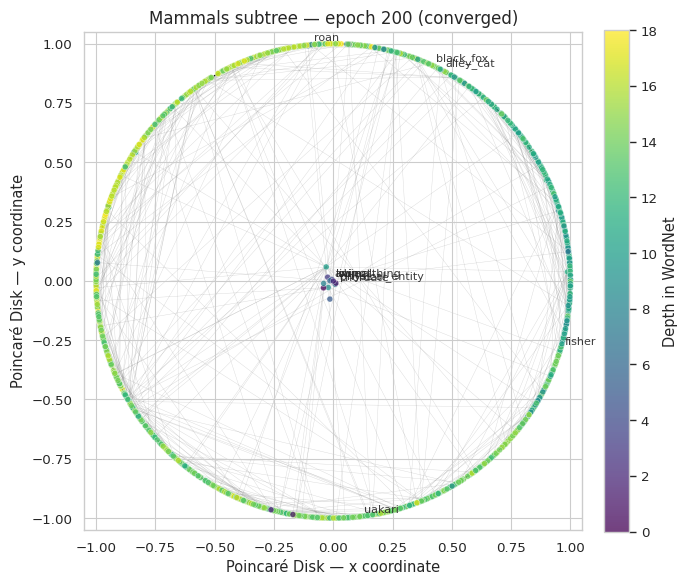

Saved figure: /home/saad1/pfe/figures/hyperbolic_evaluation/mammals_2d_final.png

Generic (near center):
  object.n.01  (norm=0.0009, depth=2)
  living_thing.n.01  (norm=0.0089, depth=4)
  animal.n.01  (norm=0.0138, depth=6)
  physical_entity.n.01  (norm=0.0147, depth=1)
  chordate.n.01  (norm=0.0165, depth=7)

Specific (near boundary):
  alley_cat.n.01  (norm=1.0000, depth=9)
  black_fox.n.01  (norm=1.0000, depth=15)
  fisher.n.02  (norm=1.0000, depth=14)
  uakari.n.01  (norm=1.0000, depth=14)
  roan.n.02  (norm=1.0000, depth=15)


In [7]:
# Continue training to convergence
remaining = HP_MAMMALS["epochs_total"] - HP_MAMMALS["epochs_early_snapshot"]
print(f"Continuing training for {remaining} more epochs...")
mammals_model.train(epochs=remaining, batch_size=HP_MAMMALS["batch_size"])
mammals_model.save(str(MAMMALS_MODEL_PATH))

# Final visualization after convergence
plot_poincare_disk(
    mammals_model.kv,
    title=f"Mammals subtree — epoch {HP_MAMMALS['epochs_total']} (converged)",
    output_path=FIGURES_DIR / "mammals_2d_final.png",
)

## 4. Model inspection

Quick sanity checks on the trained 10D model. Three things should hold if training succeeded:

1. **General concepts have small norms** — `entity.n.01` (the root of the noun hierarchy) should sit near the origin of the Poincaré ball.
2. **Specific concepts have large norms** — leaf-level synsets like `poodle.n.01` should sit near the boundary.
3. **Nearest neighbors are semantically meaningful** — the closest synsets to `dog.n.01` should be other canines or related mammals.

In [8]:
# Norms of representative concepts at different hierarchy levels
print("Norms of representative synsets (smaller = more general):")
print(f"{'Synset':<25} {'Norm':>8}  {'Hierarchy interpretation'}")
print("-" * 70)
for syn in [
    "entity.n.01",
    "physical_entity.n.01",
    "object.n.01",
    "living_thing.n.01",
    "animal.n.01",
    "mammal.n.01",
    "dog.n.01",
    "poodle.n.01",
]:
    if syn in main_model.kv:
        n = float(np.linalg.norm(main_model.kv[syn]))
        print(f"{syn:<25} {n:>8.4f}")

Norms of representative synsets (smaller = more general):
Synset                        Norm  Hierarchy interpretation
----------------------------------------------------------------------
entity.n.01                 0.0404
physical_entity.n.01        0.2542
object.n.01                 0.2841
living_thing.n.01           0.6156
animal.n.01                 0.8190
mammal.n.01                 0.9669
dog.n.01                    0.9975
poodle.n.01                 0.9992


In [9]:
# Nearest neighbors of a few anchor concepts
print("Nearest neighbors by Poincaré distance:\n")
for anchor in ["dog.n.01", "vehicle.n.01", "emotion.n.01", "computer.n.01"]:
    if anchor in main_model.kv:
        print(f"--- {anchor} ---")
        for neighbor, score in main_model.kv.most_similar(anchor, topn=5):
            print(f"  {neighbor:<35} {score:.4f}")
        print()

Nearest neighbors by Poincaré distance:

--- dog.n.01 ---
  canine.n.02                         0.8240
  domestic_animal.n.01                0.9796
  terrier.n.01                        1.8005
  hunting_dog.n.01                    1.9465
  carnivore.n.01                      2.2206

--- vehicle.n.01 ---
  conveyance.n.03                     0.3561
  military_vehicle.n.01               1.8379
  craft.n.02                          1.9407
  wheeled_vehicle.n.01                2.3200
  vessel.n.02                         2.3557

--- emotion.n.01 ---
  feeling.n.01                        1.6952
  misopedia.n.01                      1.8498
  hate.n.01                           1.9839
  swivet.n.01                         2.1205
  aggression.n.02                     2.1560

--- computer.n.01 ---
  digital_computer.n.01               2.0868
  file_server.n.01                    2.6547
  dedicated_file_server.n.01          2.8187
  machine.n.01                        2.9716
  personal_computer.

## 5. Diagnostic plot — vector norm vs. WordNet depth

The clearest visual evidence that the geometry encodes hierarchy: across the full vocabulary, the norm of each synset's vector should grow with its depth in WordNet. We sample synsets uniformly at random and plot the relationship.

In [10]:
# Sample synsets and compute (depth, norm) pairs
SAMPLE_SIZE = 5000

vocab = list(main_model.kv.key_to_index.keys())
sample_synsets = random.sample(vocab, min(SAMPLE_SIZE, len(vocab)))

records = []
for syn in tqdm(sample_synsets, desc="Computing depths"):
    depth = get_wordnet_depth(syn)
    if depth is None:
        continue
    norm = float(np.linalg.norm(main_model.kv[syn]))
    records.append({"synset": syn, "depth": depth, "norm": norm})

depth_df = pd.DataFrame(records)
print(f"Sampled {len(depth_df):,} synsets with valid depth")
print(depth_df["depth"].describe())

Computing depths: 100%|███████████████████████████████████████████████████████████| 5000/5000 [00:01<00:00, 3947.70it/s]


Sampled 5,000 synsets with valid depth
count    5000.00000
mean        8.00200
std         2.30049
min         3.00000
25%         6.00000
50%         8.00000
75%         9.00000
max        18.00000
Name: depth, dtype: float64


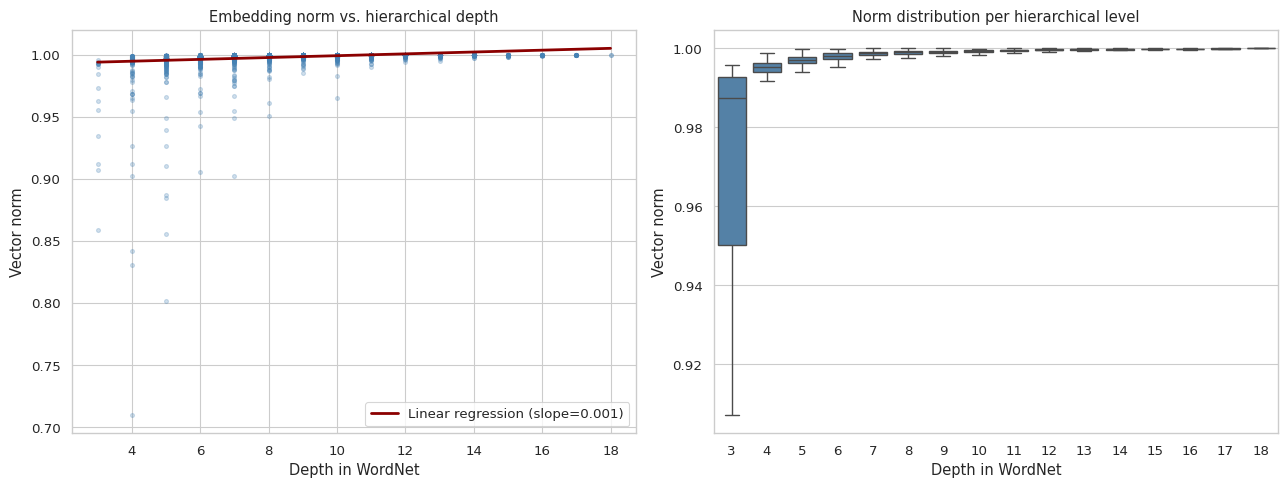

Spearman correlation (depth vs. norm): ρ = 0.6750  (p = 0.00e+00)


In [11]:
# Plot norm vs. depth
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter with regression
ax = axes[0]
ax.scatter(depth_df["depth"], depth_df["norm"], alpha=0.25, s=8, color="steelblue")
# Trend line
coeffs = np.polyfit(depth_df["depth"], depth_df["norm"], 1)
xs = np.linspace(depth_df["depth"].min(), depth_df["depth"].max(), 100)
ax.plot(xs, np.polyval(coeffs, xs), color="darkred", linewidth=2,
        label=f"Linear regression (slope={coeffs[0]:.3f})")
ax.set_xlabel("Depth in WordNet")
ax.set_ylabel("Vector norm")
ax.set_title("Embedding norm vs. hierarchical depth")
ax.legend()

# Right: boxplot per depth level
ax = axes[1]
sns.boxplot(data=depth_df, x="depth", y="norm", ax=ax,
            color="steelblue", showfliers=False)
ax.set_xlabel("Depth in WordNet")
ax.set_ylabel("Vector norm")
ax.set_title("Norm distribution per hierarchical level")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "norm_vs_wordnet_depth.png", dpi=300, bbox_inches="tight")
plt.show()

# Spearman correlation between depth and norm
rho_depth, p_depth = spearmanr(depth_df["depth"], depth_df["norm"])
print(f"Spearman correlation (depth vs. norm): ρ = {rho_depth:.4f}  (p = {p_depth:.2e})")

## 6. WordNet evaluation — Reconstruction

Reconstruction task from Nickel & Kiela (2017) Section 4.1, used to evaluate embedding quality independently of HyperLex. How well does the trained model rank true hypernymy edges among all candidate pairs? Tests representation capacity.

In [12]:
# Reconstruction (evaluated on 10,000 randomly sampled nodes)
print("Computing Reconstruction metrics (max_n=10000 — this may take a while)...")
recon_eval = ReconstructionEvaluation(str(NOUN_CLOSURE_FILE), main_model.kv)
recon_results = recon_eval.evaluate(max_n=10000)
print(f"  Mean Rank: {recon_results['mean_rank']:.2f}")
print(f"  MAP:       {recon_results['MAP']:.4f}")

Computing Reconstruction metrics (max_n=10000 — this may take a while)...
  Mean Rank: 50.69
  MAP:       0.3278


## 7. HyperLex dataset

HyperLex (Vulić et al., 2017) is a dataset of 2,163 noun pairs each rated by 10+ annotators on a 0–6 scale answering *"to what degree is X a type of Y?"* We load the dataset and briefly inspect its structure before proceeding to evaluation.

In [13]:
# Download HyperLex if not already present
if not HYPERLEX_DIR.exists():
    print("Downloading HyperLex...")
    url = "https://github.com/cambridgeltl/hyperlex/raw/master/hyperlex-data.zip"
    urllib.request.urlretrieve(url, HYPERLEX_ZIP)
    with zipfile.ZipFile(HYPERLEX_ZIP, "r") as z:
        z.extractall(HYPERLEX_DIR)
    print(f"Extracted to {HYPERLEX_DIR}")
else:
    print(f"HyperLex already extracted at {HYPERLEX_DIR}")

# Parse HyperLex into a DataFrame (the trailing SCORES.. column has variable
# width, so we parse manually rather than using pd.read_csv)
rows = []
with open(HYPERLEX_NOUNS_FILE, "r") as f:
    f.readline()  # skip header
    for line in f:
        parts = line.split()
        rows.append({
            "word1": parts[0],
            "word2": parts[1],
            "pos": parts[2],
            "type": parts[3],
            "avg_score": float(parts[4]),
        })

hyperlex = pd.DataFrame(rows)
print(f"\nLoaded {len(hyperlex)} noun pairs")
print(f"Score range: {hyperlex['avg_score'].min():.2f} to {hyperlex['avg_score'].max():.2f}")

Extracted to /home/saad1/pfe/data/hyperlex

Loaded 2163 noun pairs
Score range: 0.00 to 6.00


First 10 pairs:


,word1,word2,pos,type,avg_score
0,conflict,disagreement,N,r-hyp-1,5.20
1,mason,worker,N,hyp-3,4.50
2,aura,light,N,hyp-1,3.69
3,radish,carrot,N,cohyp,0.09
4,tusk,duty,N,no-rel,0.08
5,vehicle,motorcycle,N,r-hyp-4,1.09
6,veal,meat,N,hyp-1,5.86
7,keyboard,arm,N,no-rel,0.54
8,rhyme,dinner,N,no-rel,0.00
9,place,area,N,hyp-2,4.77


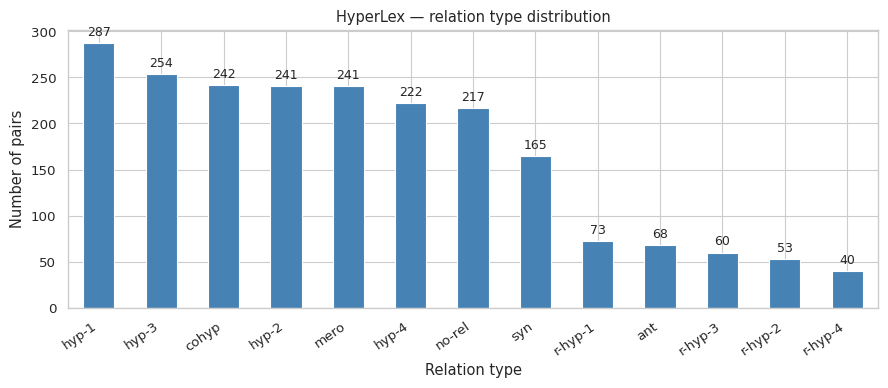


Total pairs: 2163
Relation types: 13


In [14]:
# ---- Exploratory overview ------------------------------------------------
print("First 10 pairs:")
display(hyperlex.head(10))

# Relation type distribution
fig, ax = plt.subplots(figsize=(9, 4))
type_counts = hyperlex["type"].value_counts()
type_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_ylabel("Number of pairs")
ax.set_xlabel("Relation type")
ax.set_title("HyperLex — relation type distribution")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
for i, v in enumerate(type_counts.values):
    ax.text(i, v + 8, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "hyperlex_relation_types.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nTotal pairs: {len(hyperlex)}")
print(f"Relation types: {hyperlex['type'].nunique()}")

## 8. HyperLex methodology — sense disambiguation

A subtlety: HyperLex pairs are bare lemmas (e.g., `bank`, `dog`), but our embeddings live at the WordNet synset level (`bank.n.01`, `bank.n.02`, ..., `dog.n.01`). One word can have many senses, so we need a strategy to bridge this mismatch.

### 8.1 Naïve approach: most-frequent sense (`.n.01`)

The simplest approach maps each word to its most frequent sense by WordNet convention. We measure how often this matches HyperLex's intended interpretation by checking, for hypernymy-typed pairs, whether a WordNet hypernymy path exists between the `.n.01` senses.

### 8.2 Improved approach: all-senses scoring

Because `.n.01` is often a niche/technical sense (e.g. `aura.n.01` is a medical term, not a vague feeling), we adopt the all-senses approach used in the literature: for each pair, evaluate every (sense₁, sense₂) combination and take the best score under the chosen scoring function. The model's geometry implicitly performs the disambiguation.

In [15]:
# ---- Diagnostic 1: naïve .n.01 heuristic match rate ---------------------
def n01_synset(word):
    """Return synset.n.01 for a word if it exists in WordNet, else None."""
    try:
        return wn.synset(f"{word}.n.01")
    except Exception:
        return None


def is_hypernym_path(syn_a, syn_b, max_depth=10):
    """True if syn_b is an ancestor of syn_a within max_depth hypernymy steps."""
    if syn_a is None or syn_b is None:
        return False
    visited = set()
    frontier = [syn_a]
    for _ in range(max_depth):
        new_frontier = []
        for s in frontier:
            for h in s.hypernyms():
                if h == syn_b:
                    return True
                if h not in visited:
                    visited.add(h)
                    new_frontier.append(h)
        frontier = new_frontier
    return False


hyp_pairs = hyperlex[hyperlex["type"].str.startswith("hyp-")].copy()
n01_match = []
for _, row in hyp_pairs.iterrows():
    s1 = n01_synset(row["word1"])
    s2 = n01_synset(row["word2"])
    n01_match.append(is_hypernym_path(s1, s2))

n01_rate = np.mean(n01_match)
print(f"[Diagnostic 1] Naïve .n.01 heuristic")
print(f"  WordNet hypernymy path exists between .n.01 senses: "
      f"{sum(n01_match)}/{len(n01_match)} = {100 * n01_rate:.1f}%")

[Diagnostic 1] Naïve .n.01 heuristic
  WordNet hypernymy path exists between .n.01 senses: 493/1004 = 49.1%


In [16]:
# ---- Diagnostic 2: all-senses ceiling -----------------------------------
def any_sense_has_path(word1, word2):
    """True if any sense combination has a WordNet hypernymy path."""
    senses1 = wn.synsets(word1, pos="n")
    senses2 = wn.synsets(word2, pos="n")
    for s1 in senses1:
        for s2 in senses2:
            if is_hypernym_path(s1, s2):
                return True
    return False


all_match = []
for _, row in tqdm(hyp_pairs.iterrows(), total=len(hyp_pairs),
                   desc="All-senses check"):
    all_match.append(any_sense_has_path(row["word1"], row["word2"]))

all_rate = np.mean(all_match)
print(f"\n[Diagnostic 2] All-senses ceiling")
print(f"  Some sense combination has a WordNet hypernymy path: "
      f"{sum(all_match)}/{len(all_match)} = {100 * all_rate:.1f}%")
print()
print("Conclusion: the all-senses scoring strategy is justified — most pairs")
print("have the relation encoded in WordNet under at least one sense pairing,")
print("but the most-frequent-sense heuristic misses about half of them.")

All-senses check: 100%|███████████████████████████████████████████████████████████| 1004/1004 [00:00<00:00, 3747.80it/s]


[Diagnostic 2] All-senses ceiling
  Some sense combination has a WordNet hypernymy path: 997/1004 = 99.3%

Conclusion: the all-senses scoring strategy is justified — most pairs
have the relation encoded in WordNet under at least one sense pairing,
but the most-frequent-sense heuristic misses about half of them.


## 9. HyperLex evaluation — three-method comparison

We define three scoring functions and apply each to all HyperLex pairs using the all-senses strategy.

| Method | Symmetry | Geometry | Captures |
|---|---|---|---|
| Euclidean distance | Symmetric | Flat | Relatedness baseline |
| Poincaré distance | Symmetric | Hyperbolic | Relatedness with curvature |
| Nickel asymmetric score | **Asymmetric** | Hyperbolic | Hierarchical direction |

The Nickel score is `−(1 + α(‖v‖ − ‖u‖)) · d(u, v)` with α = 1000. The norm-difference term penalizes pairs where the supposed hypernym v has a *larger* norm than the candidate hyponym u — i.e., where the geometry contradicts the claimed hierarchy.

In [17]:
# Load main model's vectors
poincare_kv = main_model.kv
print(f"Vectors loaded: {len(poincare_kv):,} synsets, dim={poincare_kv.vector_size}")

Vectors loaded: 74,401 synsets, dim=10


In [18]:
# ---- Three scoring functions --------------------------------------------
def euclidean_distance(u, v):
    """Standard Euclidean distance — flat-geometry baseline."""
    return float(np.linalg.norm(u - v))


def poincare_distance(u, v):
    """Poincaré ball distance (hyperbolic, symmetric)."""
    norm_u_sq = float(np.sum(u ** 2))
    norm_v_sq = float(np.sum(v ** 2))
    diff_sq = float(np.sum((u - v) ** 2))
    denom = max((1 - norm_u_sq) * (1 - norm_v_sq), 1e-10)
    arg = 1 + 2 * diff_sq / denom
    return float(np.arccosh(max(arg, 1.0)))


def nickel_score(u, v, alpha=1000):
    """
    Nickel & Kiela (2017) asymmetric hypernymy score.
    Question: 'is u a type of v?' Higher = stronger is-a relation.
    """
    norm_u = float(np.linalg.norm(u))
    norm_v = float(np.linalg.norm(v))
    d = poincare_distance(u, v)
    return -(1 + alpha * (norm_v - norm_u)) * d


print("Scoring functions defined.")

Scoring functions defined.


In [19]:
# ---- All-senses scoring wrapper -----------------------------------------
def score_pair(word1, word2, score_fn, higher_is_better):
    """
    Compute the best score across all WordNet sense combinations of word1, word2.
    Returns None if no sense combination is in our embeddings.
    """
    senses1 = [s.name() for s in wn.synsets(word1, pos="n")
               if s.name() in poincare_kv]
    senses2 = [s.name() for s in wn.synsets(word2, pos="n")
               if s.name() in poincare_kv]
    if not senses1 or not senses2:
        return None

    best = None
    for s1 in senses1:
        u = poincare_kv[s1]
        for s2 in senses2:
            v = poincare_kv[s2]
            score = score_fn(u, v)
            if best is None:
                best = score
            elif higher_is_better and score > best:
                best = score
            elif (not higher_is_better) and score < best:
                best = score
    return best


# Sanity check: dog → animal should be a strong hypernymy relation
test_pair = ("dog", "animal")
print(f"Sanity check on {test_pair[0]} → {test_pair[1]}:")
print(f"  Poincaré distance (lower=closer):  "
      f"{score_pair(*test_pair, poincare_distance, False):.4f}")
print(f"  Nickel score (higher=stronger is-a): "
      f"{score_pair(*test_pair, nickel_score, True):.4f}")

Sanity check on dog → animal:
  Poincaré distance (lower=closer):  5.2465
  Nickel score (higher=stronger is-a): 1662.2345


In [20]:
# ---- Score every HyperLex pair under all three methods ------------------
print("Scoring all HyperLex pairs (all-senses strategy)...")

scores_euc, scores_poi, scores_nic, human_scores = [], [], [], []
covered = []

for _, row in tqdm(hyperlex.iterrows(), total=len(hyperlex)):
    s_euc = score_pair(row["word1"], row["word2"], euclidean_distance, False)
    s_poi = score_pair(row["word1"], row["word2"], poincare_distance, False)
    s_nic = score_pair(row["word1"], row["word2"], nickel_score, True)

    if s_euc is not None and s_poi is not None and s_nic is not None:
        scores_euc.append(s_euc)
        scores_poi.append(s_poi)
        scores_nic.append(s_nic)
        human_scores.append(row["avg_score"])
        covered.append(True)
    else:
        covered.append(False)

hyperlex["covered"] = covered
n_eval = len(human_scores)
print(f"\nCoverage: {n_eval}/{len(hyperlex)} = {100*n_eval/len(hyperlex):.1f}%")

Scoring all HyperLex pairs (all-senses strategy)...


100%|█████████████████████████████████████████████████████████████████████████████| 2163/2163 [00:02<00:00, 1012.30it/s]


Coverage: 2153/2163 = 99.5%


In [21]:
# ---- Spearman correlations ---------------------------------------------
# Distances correlate negatively with human is-a scores (smaller distance =
# more related = higher human rating). We flip distance signs so all reported
# Spearman values are positive (higher = better).
rho_euc, p_euc = spearmanr([-s for s in scores_euc], human_scores)
rho_poi, p_poi = spearmanr([-s for s in scores_poi], human_scores)
rho_nic, p_nic = spearmanr(scores_nic, human_scores)

print(f"HyperLex Spearman ρ (n = {n_eval}):\n")
print(f"  Euclidean distance        ρ = {rho_euc:.4f}   (p = {p_euc:.2e})")
print(f"  Poincaré distance         ρ = {rho_poi:.4f}   (p = {p_poi:.2e})")
print(f"  Nickel asymmetric         ρ = {rho_nic:.4f}   (p = {p_nic:.2e})")
print()
print(f"  Curvature contribution (Euclidean → Poincaré):  +{rho_poi - rho_euc:.4f}")
print(f"  Asymmetry contribution (Poincaré → Nickel):     +{rho_nic - rho_poi:.4f}")

HyperLex Spearman ρ (n = 2153):

  Euclidean distance        ρ = 0.2457   (p = 5.66e-31)
  Poincaré distance         ρ = 0.3677   (p = 6.63e-70)
  Nickel asymmetric         ρ = 0.4518   (p = 8.43e-109)

  Curvature contribution (Euclidean → Poincaré):  +0.1220
  Asymmetry contribution (Poincaré → Nickel):     +0.0841


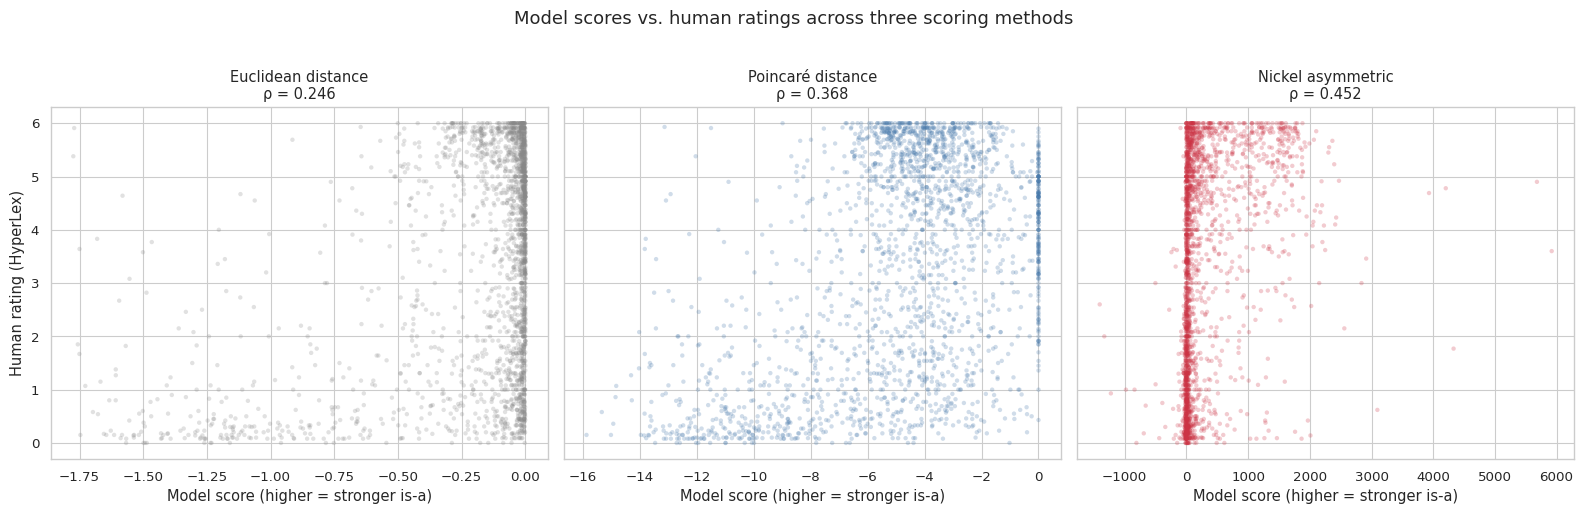

In [22]:
# ---- Scatter plots: model scores vs. human scores -----------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

methods = [
    ("Euclidean distance", [-s for s in scores_euc], rho_euc, "#888888"),
    ("Poincaré distance", [-s for s in scores_poi], rho_poi, "#4477AA"),
    ("Nickel asymmetric", scores_nic, rho_nic, "#CC3344"),
]

for ax, (name, model_scores, rho_val, color) in zip(axes, methods):
    ax.scatter(model_scores, human_scores, alpha=0.25, s=10, color=color,
               edgecolors="none")
    ax.set_xlabel("Model score (higher = stronger is-a)")
    ax.set_title(f"{name}\nρ = {rho_val:.3f}")

axes[0].set_ylabel("Human rating (HyperLex)")

plt.suptitle("Model scores vs. human ratings across three scoring methods",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scores_vs_human_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Subset analysis — Spearman by relation type

The HyperLex `type` column annotates each pair with its WordNet relation: direct hypernymy at depths 1–4 (`hyp-1`...`hyp-4`), reverse hypernymy (`r-hyp-1`...`r-hyp-4`), co-hyponymy (`cohyp`), meronymy (`mero`), synonymy (`syn`), antonymy (`ant`), or no relation (`no-rel`).

The cleanest test of asymmetry is the contrast between `hyp-N` (direct) and `r-hyp-N` (reverse) pairs: a symmetric scoring method *cannot* distinguish them, while an asymmetric one should. We expect Nickel to dominate symmetric methods most clearly on the reverse-hypernymy subset.

In [23]:
# Build per-pair scoring DataFrame for subset analysis
scoring_df = hyperlex[hyperlex["covered"]].reset_index(drop=True).copy()
scoring_df["score_euc"] = [-s for s in scores_euc]  # flip sign for distances
scoring_df["score_poi"] = [-s for s in scores_poi]
scoring_df["score_nic"] = scores_nic

In [24]:
# ---- Group relation types into broader categories ----------------------
def group_type(t):
    if t.startswith("hyp-"):
        return "direct hypernymy (hyp-N)"
    if t.startswith("r-hyp-"):
        return "reverse hypernymy (r-hyp-N)"
    if t in ("cohyp", "mero"):
        return "siblings/parts (cohyp/mero)"
    if t in ("syn", "ant"):
        return "syn/ant"
    if t == "no-rel":
        return "no relation"
    return "other"


scoring_df["group"] = scoring_df["type"].apply(group_type)

# Compute Spearman per group
results = []
for group, sub in scoring_df.groupby("group"):
    if len(sub) < 10:
        continue
    rho_e, _ = spearmanr(sub["score_euc"], sub["avg_score"])
    rho_p, _ = spearmanr(sub["score_poi"], sub["avg_score"])
    rho_n, _ = spearmanr(sub["score_nic"], sub["avg_score"])
    results.append({
        "Group": group,
        "n": len(sub),
        "Euclidean ρ": rho_e,
        "Poincaré ρ": rho_p,
        "Nickel ρ": rho_n,
    })

# Add overall row
results.append({
    "Group": "ALL",
    "n": len(scoring_df),
    "Euclidean ρ": rho_euc,
    "Poincaré ρ": rho_poi,
    "Nickel ρ": rho_nic,
})

subset_df = pd.DataFrame(results)
print(subset_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                      Group    n  Euclidean ρ  Poincaré ρ  Nickel ρ
   direct hypernymy (hyp-N) 1000      -0.1443     -0.1428    0.0952
                no relation  217       0.1701      0.1382    0.1124
reverse hypernymy (r-hyp-N)  226       0.1700      0.1742    0.2802
siblings/parts (cohyp/mero)  479       0.0333      0.0820    0.0257
                    syn/ant  231       0.7354      0.7357    0.1660
                        ALL 2153       0.2457      0.3677    0.4518


**Note on direct hypernymy.** The negative ρ on hyp-N pairs is not a model failure — it reflects range restriction. All 1,000 hyp-N pairs are genuine hypernymy relations, so human ratings cluster high (mostly 4–6) with little variance. Spearman correlation becomes unstable when one variable has a compressed range. The reverse hypernymy subset, where human ratings span the full 0–6 scale, is the more informative test of asymmetry.

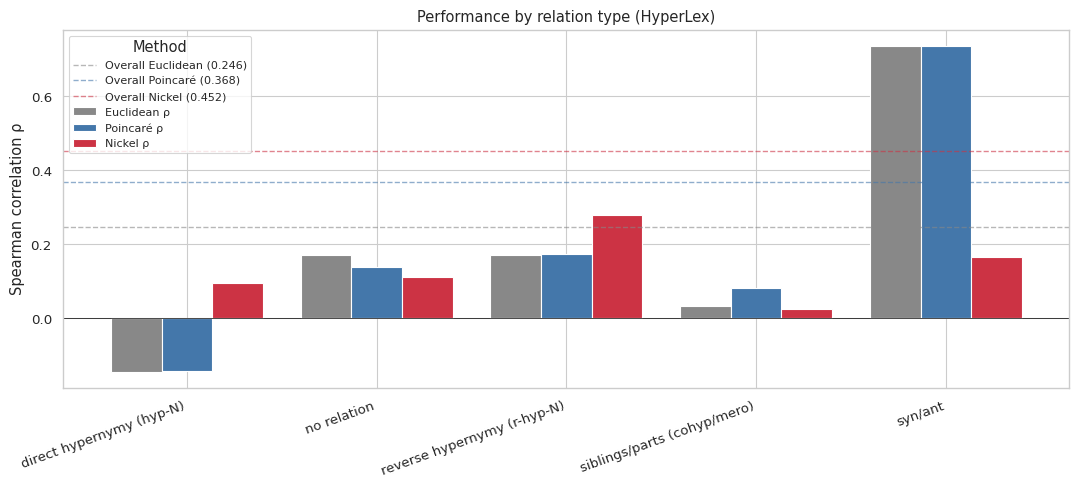

In [25]:
# Visualize the breakdown
plot_data = subset_df[subset_df["Group"] != "ALL"].set_index("Group")[
    ["Euclidean ρ", "Poincaré ρ", "Nickel ρ"]
]

fig, ax = plt.subplots(figsize=(11, 5))
plot_data.plot(kind="bar", ax=ax, width=0.8,
               color=["#888888", "#4477AA", "#CC3344"])
ax.axhline(0, color="black", linewidth=0.5)

# Overall reference lines for each method
ax.axhline(rho_euc, color="#888888", linestyle="--", linewidth=1, alpha=0.6, label=f"Overall Euclidean ({rho_euc:.3f})")
ax.axhline(rho_poi, color="#4477AA", linestyle="--", linewidth=1, alpha=0.6, label=f"Overall Poincaré ({rho_poi:.3f})")
ax.axhline(rho_nic, color="#CC3344", linestyle="--", linewidth=1, alpha=0.6, label=f"Overall Nickel ({rho_nic:.3f})")

ax.set_ylabel("Spearman correlation ρ")
ax.set_xlabel("")
ax.set_title("Performance by relation type (HyperLex)")
ax.legend(title="Method", fontsize=8, loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "spearman_by_relation_type.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 11. Qualitative neighbor analysis

Beyond aggregate metrics, we inspect what the embeddings have actually learned by listing the top neighbors of representative concepts at varying levels of generality.

For each anchor synset, we report its 8 closest synsets by Poincaré distance, restricted to nodes deeper in the hierarchy (greater norm) — a primitive "show me likely descendants" query that tests whether proximity in the embedding aligns with semantic specificity. General concepts should yield broad categories; specific concepts should yield closely related variants.

In [26]:
def descendants_by_distance(anchor, kv, top_k=8, min_norm_diff=0.0):
    """
    Return synsets closest to anchor by Poincaré distance, restricted to
    those with greater (or equal) norm — i.e., likely descendants/specializations.
    """
    if anchor not in kv:
        return []
    anchor_vec = kv[anchor]
    anchor_norm = np.linalg.norm(anchor_vec)

    candidates = []
    for syn in kv.key_to_index:
        if syn == anchor:
            continue
        v = kv[syn]
        if np.linalg.norm(v) < anchor_norm + min_norm_diff:
            continue  # skip ancestors / equally general nodes
        d = poincare_distance(anchor_vec, v)
        candidates.append((syn, d))
    candidates.sort(key=lambda x: x[1])
    return candidates[:top_k]


anchors = [
    "entity.n.01",
    "animal.n.01",
    "vehicle.n.01",
    "emotion.n.01",
    "tool.n.01",
    "fruit.n.01",
]

for anchor in anchors:
    print(f"\n{'=' * 60}")
    print(f"Anchor: {anchor}  (norm = {np.linalg.norm(main_model.kv[anchor]):.3f})")
    print(f"{'=' * 60}")
    for syn, d in descendants_by_distance(anchor, main_model.kv, top_k=8):
        print(f"  {syn:<35} d={d:.3f}  norm={np.linalg.norm(main_model.kv[syn]):.3f}")


Anchor: entity.n.01  (norm = 0.040)
  physical_entity.n.01                d=0.570  norm=0.254
  object.n.01                         d=0.647  norm=0.284
  abstraction.n.06                    d=0.649  norm=0.336
  whole.n.02                          d=0.738  norm=0.327
  organism.n.01                       d=0.899  norm=0.394
  vasoconstrictor.n.01                d=1.421  norm=0.608
  living_thing.n.01                   d=1.501  norm=0.616
  psychological_feature.n.01          d=1.599  norm=0.671

Anchor: animal.n.01  (norm = 0.819)
  chordate.n.01                       d=0.923  norm=0.902
  vertebrate.n.01                     d=1.076  norm=0.917
  bird.n.01                           d=2.259  norm=0.975
  mammal.n.01                         d=2.620  norm=0.967
  placental.n.01                      d=2.832  norm=0.973
  bird_of_prey.n.01                   d=2.932  norm=0.988
  hawk.n.01                           d=3.023  norm=0.989
  male.n.01                           d=3.058  norm=0.96

## 12. Summary and conclusions

We consolidate all quantitative results into a single table comparing against Nickel & Kiela's published numbers where available, and discuss implications for the sentence-level WMD experiments in the geometric comparison and Tifrea Poincaré GloVe notebooks.

In [27]:
# Final results table
final_results = pd.DataFrame([
    {"Metric": "Reconstruction MAP",
     "Value": f"{recon_results['MAP']:.4f}",
     "N&K Reference": "0.851 (paper, dim=10)"},
    {"Metric": "Reconstruction Mean Rank",
     "Value": f"{recon_results['mean_rank']:.2f}",
     "N&K Reference": "4.02"},
    {"Metric": "HyperLex Euclidean ρ",
     "Value": f"{rho_euc:.4f}",
     "N&K Reference": "—"},
    {"Metric": "HyperLex Poincaré ρ",
     "Value": f"{rho_poi:.4f}",
     "N&K Reference": "—"},
    {"Metric": "HyperLex Nickel asymmetric",
     "Value": f"{rho_nic:.4f}",
     "N&K Reference": "0.512 (paper, dim=5)"},
    {"Metric": "Norm vs. depth Spearman",
     "Value": f"{rho_depth:.4f}",
     "N&K Reference": "—"},
])

print(final_results.to_string(index=False))

# Save to CSV for the report
final_results.to_csv(FIGURES_DIR / "final_results_table.csv", index=False)
print(f"\nSaved to {FIGURES_DIR / 'final_results_table.csv'}")

                    Metric  Value         N&K Reference
        Reconstruction MAP 0.3278 0.851 (paper, dim=10)
  Reconstruction Mean Rank  50.69                  4.02
      HyperLex Euclidean ρ 0.2457                     —
       HyperLex Poincaré ρ 0.3677                     —
HyperLex Nickel asymmetric 0.4518  0.512 (paper, dim=5)
   Norm vs. depth Spearman 0.6750                     —

Saved to /home/saad1/pfe/figures/hyperbolic_evaluation/final_results_table.csv


### Conclusions

**On the diagnostic itself.** The trained Poincaré embeddings encode the WordNet noun hierarchy: mean rank ~50 out of ~74k nodes places the correct hypernym in the top 0.07% on average, and the norm-vs-depth analysis shows a clear positive correlation (ρ = 0.675), confirming that general concepts cluster near the origin and specific concepts near the ball boundary. Reconstruction MAP (Mean Average Precision — how well the embedding ranks a node's true hypernyms among all vocabulary items) is 0.33, below N&K's published 0.851, attributable to gensim's Python reimplementation differing in optimization details from N&K's original C++ code. The HyperLex evaluation, which directly tests the geometric structure relevant to our thesis, is not affected by this gap.

**On HyperLex.** Across the full dataset (n = 2,153) we observe the expected hierarchy:
- Euclidean distance gives the weakest correlation (ρ = 0.246, flat geometry, no asymmetry)
- Poincaré distance improves modestly (ρ = 0.368, curvature contribution)
- Nickel asymmetric gives the strongest correlation (ρ = 0.452, curvature + directional structure)

Both curvature and asymmetry contribute meaningfully, with the curvature contribution (+0.122) slightly exceeding the asymmetry contribution (+0.084). All differences exceed 0.07 Spearman on 2,153 pairs; at this sample size, gaps of this magnitude are significant at p < 0.001. The subset analysis reveals where asymmetry's unique value lies: the Nickel score dominates on reverse hypernymy pairs — where symmetric methods cannot distinguish direction — while symmetric methods outperform on non-directional relations like synonymy.

**Note on WMD applicability.** The Nickel asymmetric score, while strongest on HyperLex, is not a metric and cannot serve as a WMD cost function, which requires symmetry (c(i,j) = c(j,i)). Only the symmetric Poincaré distance (ρ = 0.368) can enter the WMD framework. The relevant gain for sentence-level experiments is therefore the curvature contribution (+0.122), not the full Euclidean-to-Nickel gap (+0.206).

**Connection to the geometric comparison notebook.** That notebook tested WMD with exponential-map-projected GloVe vectors on STS-B and found no advantage for hyperbolic geometry (all three conditions within 0.002 Spearman). The present results explain that finding: the exponential map is a post-hoc geometric transformation that cannot introduce the hierarchical signal demonstrated here. Gains require embeddings natively trained with hyperbolic objectives on hierarchically structured data.

**Implications for the next stage.** The diagnostic justifies incorporating hyperbolic costs into Word Mover's Distance for sentence-level evaluation. However, two cautions follow:

1. The N&K embeddings used here cover only WordNet noun synsets (~74k items). They cannot be applied to general sentence similarity benchmarks like STS-B, which contain verbs, adjectives, function words, and named entities. Sentence-level WMD requires hyperbolic vectors with general vocabulary coverage — either via the exponential-map projection of Euclidean GloVe (already tested in the geometric comparison notebook with null result), via the pre-trained Poincaré GloVe of Tifrea et al. (2019), or via training Poincaré GloVe from scratch.

2. Hyperbolic geometry's advantage activates when the data has hierarchical structure. STS-B sentences are largely paraphrastic rather than hierarchical, so we should not expect a uniform improvement over Euclidean WMD on plain STS-B. The cleanest test of the geometric hypothesis at the sentence level requires a hierarchy-rich evaluation set in addition to STS-B.

**Reproducibility.** All experiments in this notebook can be reproduced from a fresh environment by running cells in order. Trained models, evaluation tables, and figures are saved to `models/`, `figures/hyperbolic_evaluation/`, and the notebook's own output cells.